# Desenie w Matplotlib: Podstawowe Wzory (Hatching)

**Hatching** (kreskowanie/deseniowanie) to wzory tekstur które można dodać do wypełnień na wykresach.

## Po co używać deseni?

✅ **Druk czarno-biały** - odróżnienie kategorii bez koloru  
✅ **Accessibility** - osoby z daltonizmem lepiej widzą różnice  
✅ **Podwójne kodowanie** - kolor + deseń = więcej informacji  
✅ **Estetyka** - profesjonalny wygląd publikacji naukowych  

---

In [12]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

## 1. Podstawy - parametr `hatch`

Każda funkcja rysująca wypełnienia (bar, barh, fill, pie, etc.) przyjmuje parametr `hatch`.

**Składnia:**
```python
ax.bar(x, y, hatch='///')  # Ukośne linie
```

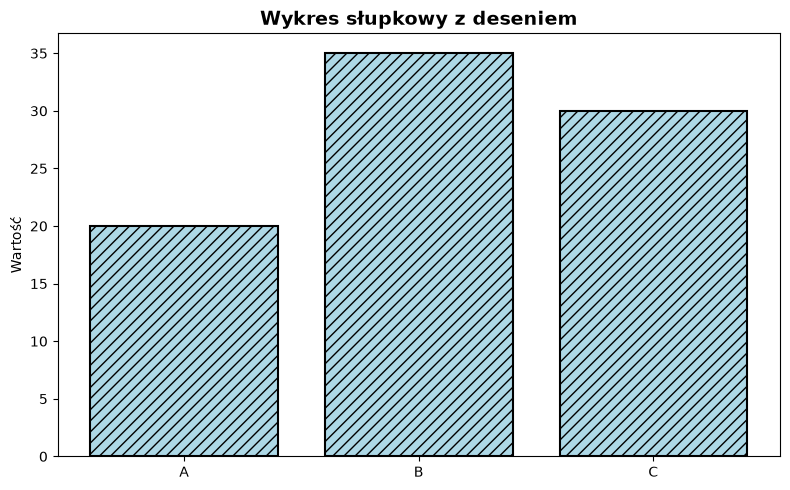

In [13]:
# Prosty przykład
fig, ax = plt.subplots(figsize=(8, 5))

x = ['A', 'B', 'C']
y = [20, 35, 30]

ax.bar(x, y, color='lightblue', edgecolor='black', linewidth=1.5, hatch='///')

ax.set_title('Wykres słupkowy z deseniem', fontsize=14, fontweight='bold')
ax.set_ylabel('Wartość')

plt.tight_layout()
plt.show()

## 2. Wszystkie dostępne wzory

Matplotlib ma **10 podstawowych wzorów**:

| Pattern | Opis |
|---------|------|
| `/` | Ukośne linie w prawo (/) |
| `\` | Ukośne linie w lewo (\) |
| `|` | Linie pionowe |
| `-` | Linie poziome |
| `+` | Krzyżyki (+) |
| `x` | Ukośne krzyżyki (×) |
| `o` | Małe kółka |
| `O` | Duże kółka |
| `.` | Kropki |
| `*` | Gwiazdki |

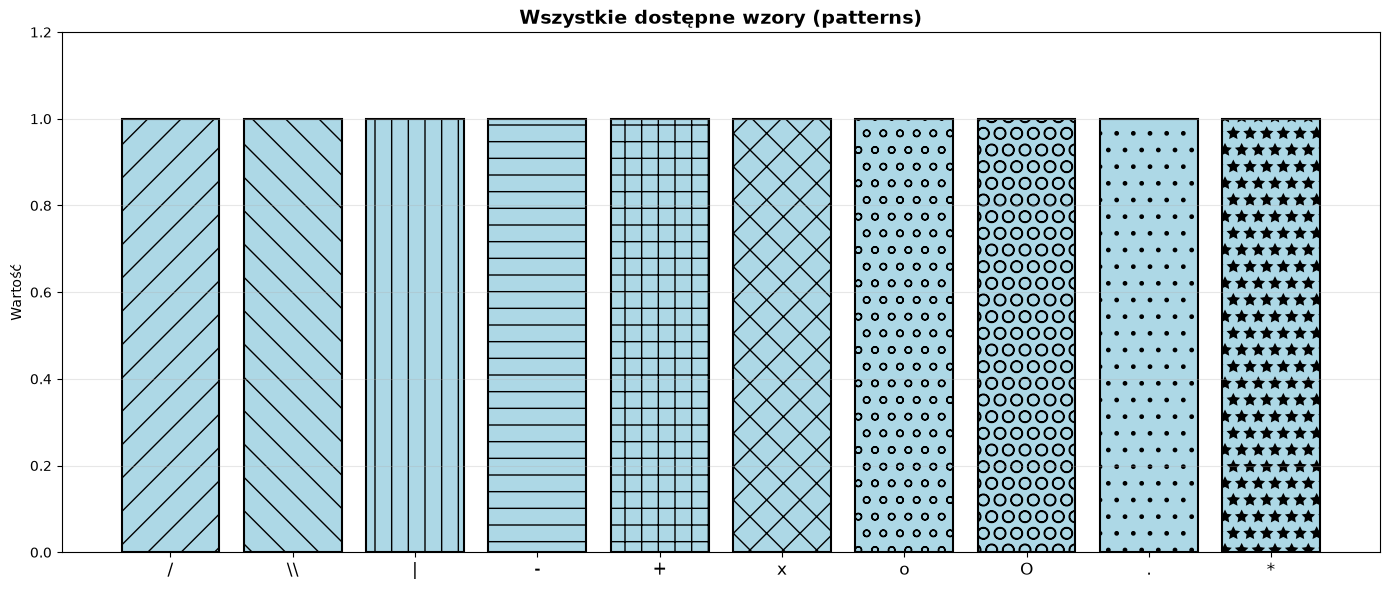

In [14]:
# Wszystkie wzory obok siebie
patterns = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']
labels = ['/', '\\\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(patterns))
bars = ax.bar(x, [1]*len(patterns), color='lightblue', edgecolor='black', linewidth=1.5)

# Dodaj desenie
for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.2)
ax.set_title('Wszystkie dostępne wzory (patterns)', fontsize=14, fontweight='bold')
ax.set_ylabel('Wartość')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Gęstość wzoru

**Ilość powtórzeń** znaku kontroluje gęstość desenia:

- `'/'` - rzadki (pojedyncze linie)
- `'//'` - średni (podwójne linie)
- `'///'` - gęsty (potrójne linie)
- `'////'` - bardzo gęsty (poczwórne linie)

**Im więcej powtórzeń, tym gęstszy wzór!**

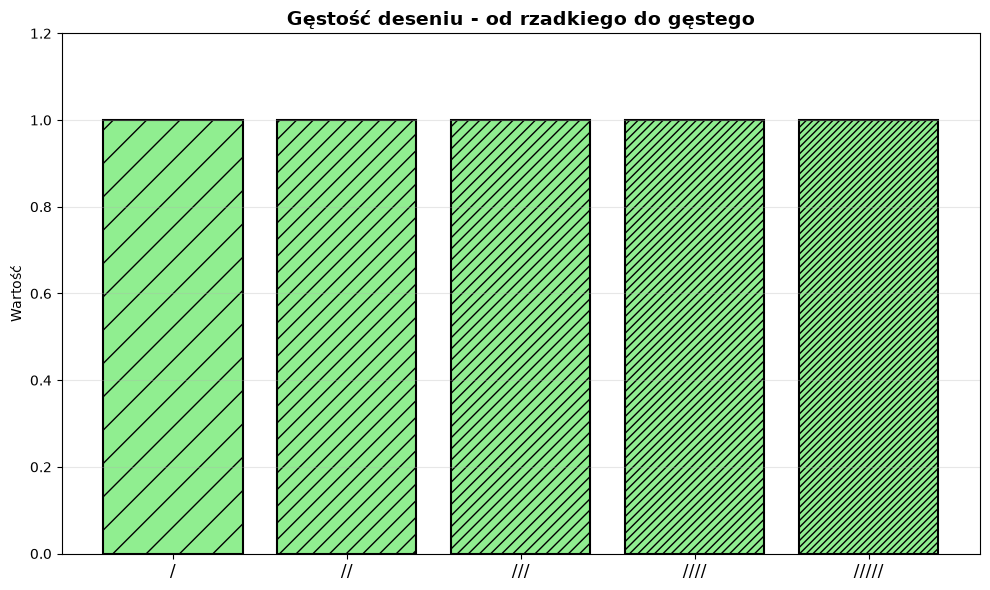

In [15]:
# Różne gęstości
densities = ['/', '//', '///', '////', '/////']  
labels_dens = ['/', '//', '///', '////', '/////']  

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(densities))
bars = ax.bar(x, [1]*len(densities), color='lightgreen', edgecolor='black', linewidth=1.5)

for bar, pattern in zip(bars, densities):
    bar.set_hatch(pattern)

ax.set_xticks(x)
ax.set_xticklabels(labels_dens, fontsize=12)
ax.set_ylim(0, 1.2)
ax.set_title('Gęstość deseniu - od rzadkiego do gęstego', fontsize=14, fontweight='bold')
ax.set_ylabel('Wartość')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Kombinacje wzorów

Możesz **łączyć różne wzory** w jednym deseniu:

```python
'///+'   # Ukośne linie + krzyżyki
'x*'     # Krzyżyki + gwiazdki
'||--'   # Linie pionowe + poziome
'//oo'   # Ukośne linie + kółka
```

**Kolejność nie ma znaczenia** - wzory się nakładają.

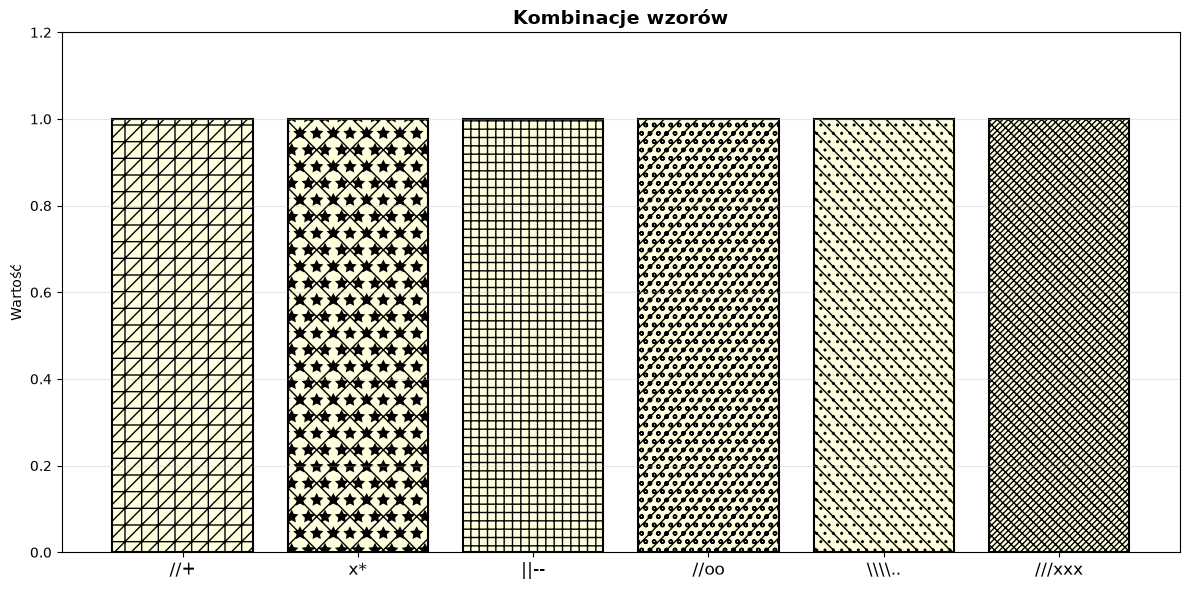

In [16]:
# Kombinacje wzorów
combinations = ['//+', 'x*', '||--', '//oo', '\\\\..', '///xxx']
labels_comb = ['//+', 'x*', '||--', '//oo', '\\\\\\\\..', '///xxx']

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(combinations))
bars = ax.bar(x, [1]*len(combinations), color='lightyellow', edgecolor='black', linewidth=1.5)

for bar, pattern in zip(bars, combinations):
    bar.set_hatch(pattern)

ax.set_xticks(x)
ax.set_xticklabels(labels_comb, fontsize=12)
ax.set_ylim(0, 1.2)
ax.set_title('Kombinacje wzorów', fontsize=14, fontweight='bold')
ax.set_ylabel('Wartość')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Praktyczny przykład - różne desenie dla kategorii

**Typowe użycie:** Każda kategoria = inny deseń

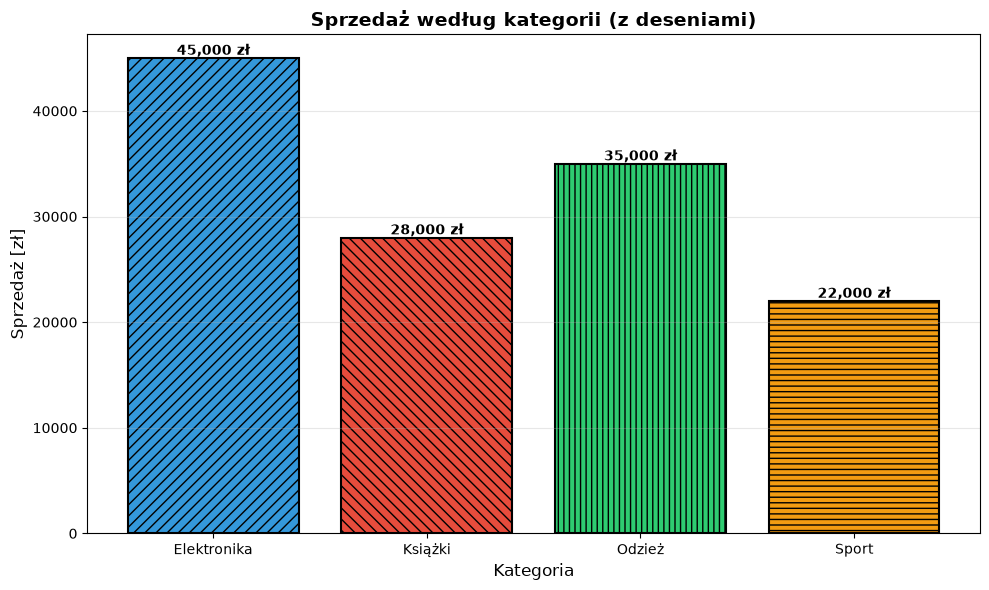

In [17]:
# Sprzedaż według kategorii - każda kategoria = inny deseń
fig, ax = plt.subplots(figsize=(10, 6))

kategorie = ['Elektronika', 'Książki', 'Odzież', 'Sport']
wartosci = [45000, 28000, 35000, 22000]

# Różne desenie i kolory
patterns = ['///', '\\\\\\', '|||', '---']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

bars = ax.bar(kategorie, wartosci, color=colors, edgecolor='black', linewidth=1.5)

# Dodaj desenie
for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)

ax.set_title('Sprzedaż według kategorii (z deseniami)', fontsize=14, fontweight='bold')
ax.set_ylabel('Sprzedaż [zł]', fontsize=12)
ax.set_xlabel('Kategoria', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Dodaj wartości na słupkach
for i, (bar, val) in enumerate(zip(bars, wartosci)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:,.0f} zł',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Wykres poziomy (barh) z deseniami

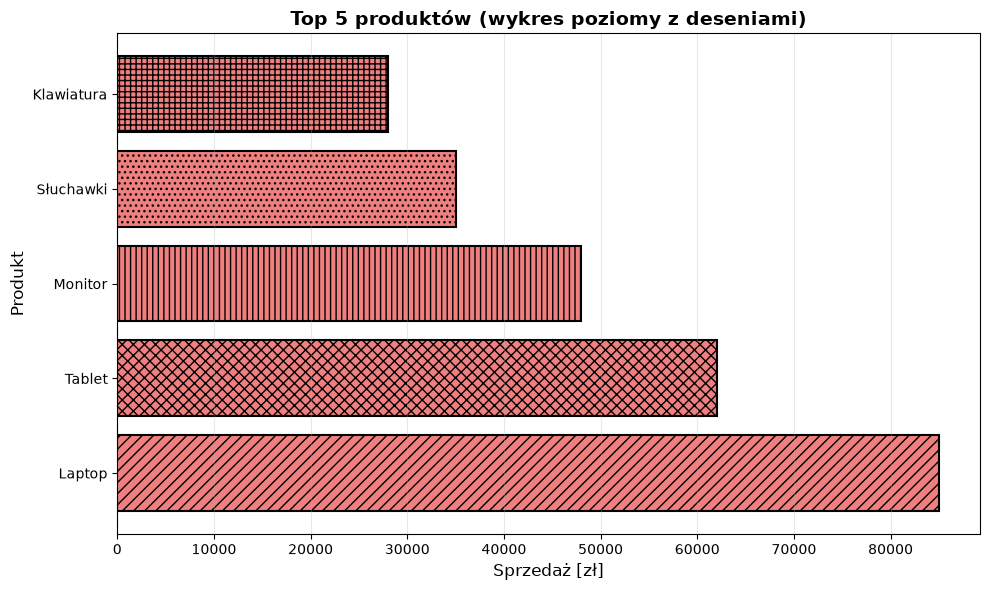

In [18]:
# Top produktów - wykres poziomy
fig, ax = plt.subplots(figsize=(10, 6))

produkty = ['Laptop', 'Tablet', 'Monitor', 'Słuchawki', 'Klawiatura']
wartosci = [85000, 62000, 48000, 35000, 28000]

patterns = ['///', 'xxx', '|||', '...', '+++']

bars = ax.barh(produkty, wartosci, color='lightcoral', edgecolor='black', linewidth=1.5)

for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)

ax.set_title('Top 5 produktów (wykres poziomy z deseniami)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sprzedaż [zł]', fontsize=12)
ax.set_ylabel('Produkt', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Grouped bar chart z deseniami

**Podwójne kodowanie:** Kolor + deseń dla lepszej czytelności

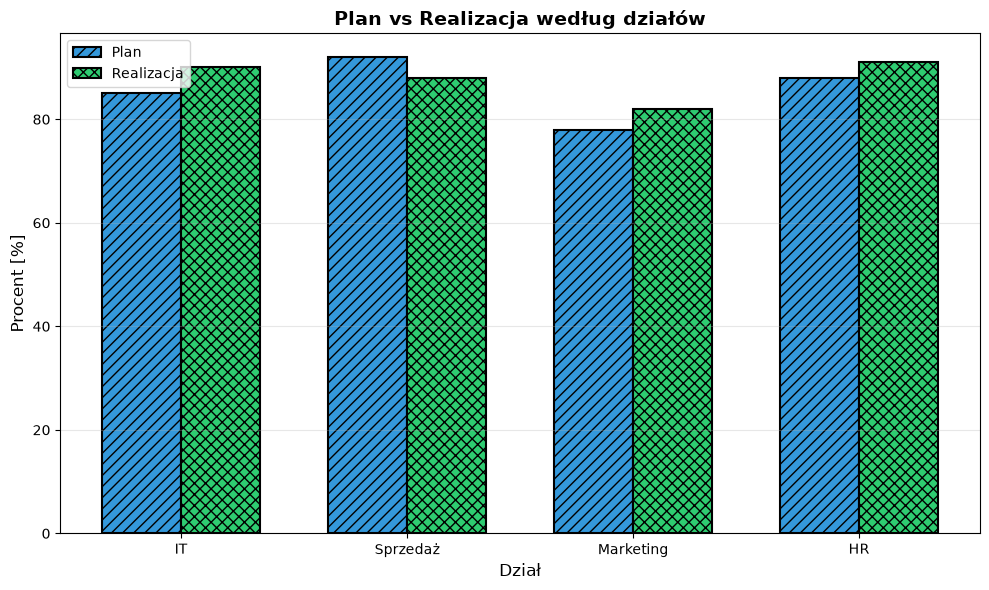

In [19]:
# Porównanie dwóch metryk z deseniami
fig, ax = plt.subplots(figsize=(10, 6))

dzialy = ['IT', 'Sprzedaż', 'Marketing', 'HR']
plan = [85, 92, 78, 88]
realizacja = [90, 88, 82, 91]

x = np.arange(len(dzialy))
width = 0.35

bars1 = ax.bar(x - width/2, plan, width, label='Plan', 
               color='#3498db', edgecolor='black', linewidth=1.5, hatch='///')
bars2 = ax.bar(x + width/2, realizacja, width, label='Realizacja', 
               color='#2ecc71', edgecolor='black', linewidth=1.5, hatch='xxx')

ax.set_title('Plan vs Realizacja według działów', fontsize=14, fontweight='bold')
ax.set_ylabel('Procent [%]', fontsize=12)
ax.set_xlabel('Dział', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(dzialy)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Stacked bar chart z deseniami

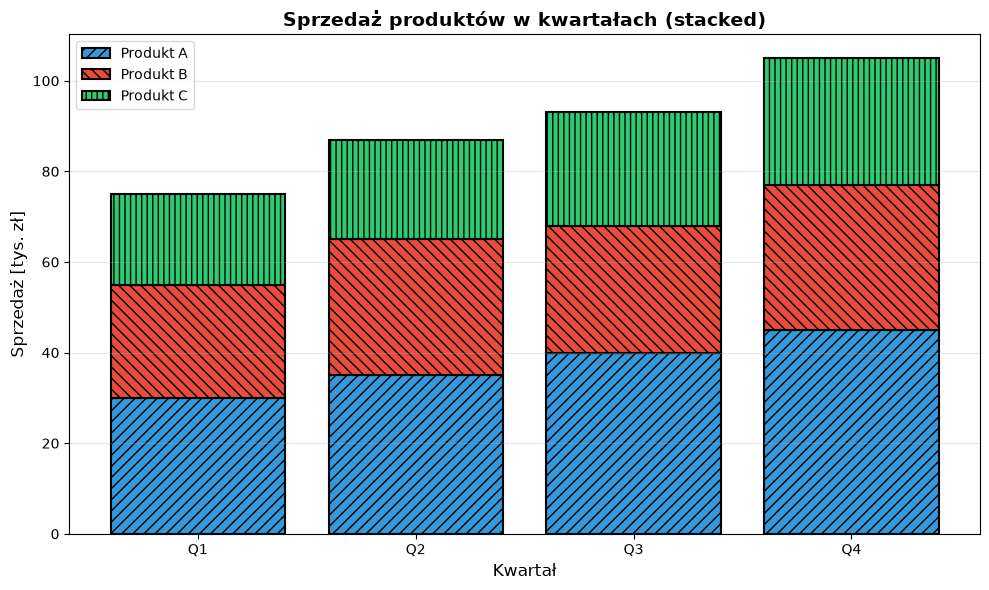

In [20]:
# Stacked bar z deseniami
fig, ax = plt.subplots(figsize=(10, 6))

kwartaly = ['Q1', 'Q2', 'Q3', 'Q4']
produkt_a = [30, 35, 40, 45]
produkt_b = [25, 30, 28, 32]
produkt_c = [20, 22, 25, 28]

x = np.arange(len(kwartaly))

bars1 = ax.bar(x, produkt_a, label='Produkt A', 
               color='#3498db', edgecolor='black', linewidth=1.5, hatch='///')
bars2 = ax.bar(x, produkt_b, bottom=produkt_a, label='Produkt B', 
               color='#e74c3c', edgecolor='black', linewidth=1.5, hatch='\\\\\\')  
bars3 = ax.bar(x, produkt_c, bottom=np.array(produkt_a)+np.array(produkt_b), 
               label='Produkt C', color='#2ecc71', edgecolor='black', linewidth=1.5, hatch='|||')

ax.set_title('Sprzedaż produktów w kwartałach (stacked)', fontsize=14, fontweight='bold')
ax.set_ylabel('Sprzedaż [tys. zł]', fontsize=12)
ax.set_xlabel('Kwartał', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(kwartaly)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Customizacja - kolor linii deseniu

**Domyślnie:** deseń jest rysowany tym samym kolorem co `edgecolor`.

Można to zmienić ustawiając `rcParams`:

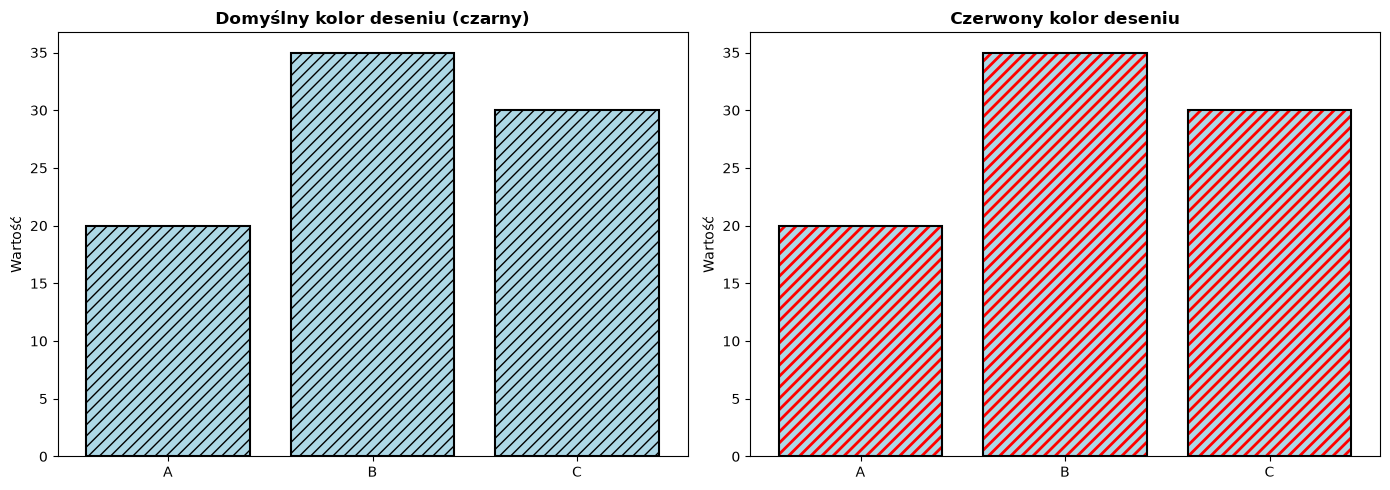

In [21]:
# Zmiana koloru deseniu
import matplotlib as mpl

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = ['A', 'B', 'C']
y = [20, 35, 30]

# Lewy - domyślny kolor (czarny)
ax1.bar(x, y, color='lightblue', edgecolor='black', linewidth=1.5, hatch='///')
ax1.set_title('Domyślny kolor deseniu (czarny)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Wartość')

# Prawy - czerwony kolor
mpl.rcParams['hatch.color'] = 'red'
mpl.rcParams['hatch.linewidth'] = 2.0

ax2.bar(x, y, color='lightblue', edgecolor='black', linewidth=1.5, hatch='///')
ax2.set_title('Czerwony kolor deseniu', fontsize=12, fontweight='bold')
ax2.set_ylabel('Wartość')

# Przywróć domyślne
mpl.rcParams['hatch.color'] = 'black'
mpl.rcParams['hatch.linewidth'] = 1.0

plt.tight_layout()
plt.show()

## 10. Desenie w druku czarno-białym

**Główne zastosowanie:** Publikacje naukowe, raporty drukowane w B&W

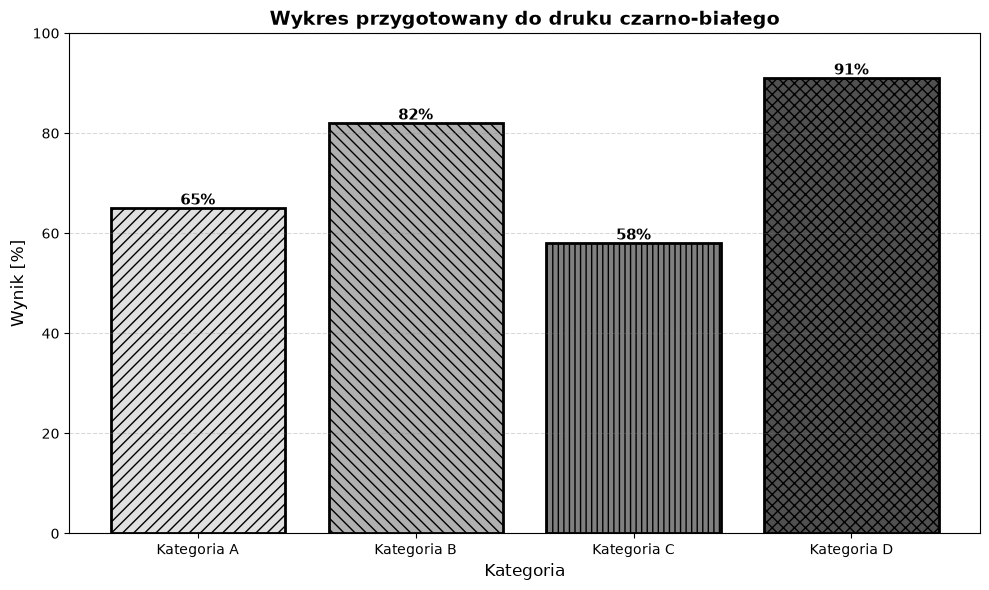

In [22]:
# Wykres przygotowany do druku B&W
fig, ax = plt.subplots(figsize=(10, 6))

kategorie = ['Kategoria A', 'Kategoria B', 'Kategoria C', 'Kategoria D']
wartosci = [65, 82, 58, 91]

# Różne odcienie szarości + różne desenie
colors_bw = ['#e0e0e0', '#b0b0b0', '#808080', '#505050']  # Od jasnego do ciemnego
patterns_bw = ['///', '\\\\\\', '|||', 'xxx']

bars = ax.bar(kategorie, wartosci, color=colors_bw, edgecolor='black', linewidth=2)

for bar, pattern in zip(bars, patterns_bw):
    bar.set_hatch(pattern)

ax.set_title('Wykres przygotowany do druku czarno-białego', fontsize=14, fontweight='bold')
ax.set_ylabel('Wynik [%]', fontsize=12)
ax.set_xlabel('Kategoria', fontsize=12)
ax.grid(axis='y', alpha=0.3, color='gray', linestyle='--')
ax.set_ylim(0, 100)

# Dodaj wartości
for bar, val in zip(bars, wartosci):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Podsumowanie

### Kluczowe punkty:

✅ **Parametr `hatch`** - dodaj do `bar()`, `barh()`, `fill()`, `pie()`  
✅ **10 podstawowych wzorów** - `/`, `\`, `|`, `-`, `+`, `x`, `o`, `O`, `.`, `*`  
✅ **Gęstość** - powtarzaj znak: `'/'` (rzadki), `'//'` (średni), `'///'` (gęsty)  
✅ **Kombinacje** - łącz wzory: `'//+'`, `'x*'`, `'||--'`  
✅ **Edgecolor** - zawsze dodaj `edgecolor='black'` dla wyraźnych granic  

### Kiedy używać:

- 📄 **Publikacje naukowe** - druk czarno-biały
- ♿ **Accessibility** - wsparcie dla osób z daltonizmem
- 🎨 **Podwójne kodowanie** - kolor + deseń = więcej informacji
- 🖨️ **Druk** - lepszy kontrast na papierze

### Ważne:

⚠️ **Plotly NIE wspiera hatching** - jeśli potrzebujesz deseni, używaj matplotlib!  

---